# 06. Виды детали для эмбеддингов

| вход | выход |
|---|---|
| `part_mask` из этапа 05 (маска только линий детали, без текста и размеров) | отдельные кропы каждого вида, готовые к подаче в модель эмбеддингов |

Лист чертежа обычно несет не один вид детали, а несколько ортогональных проекций, разнесенных
пустым полем листа. Правила отбора компонент из этапа 05 уже снимают текст, размерные линии и
рамку штампа, поэтому в `part_mask` остаются только сами виды — но одним массивом на весь лист.
Задача этого этапа геометрическая: связные куски маски на растре (не ребра графа скелета, а именно
пиксельные blob'ы) соответствуют отдельным видам, и их нужно развести по отдельным кропам
оригинального изображения с отступом, слить те, что разошлись из-за разрыва линии, и откинуть то,
что осталось от шума.


20.jpg: (11572, 18478), dtype=bool
чернил 0.4% | связных кусков 4


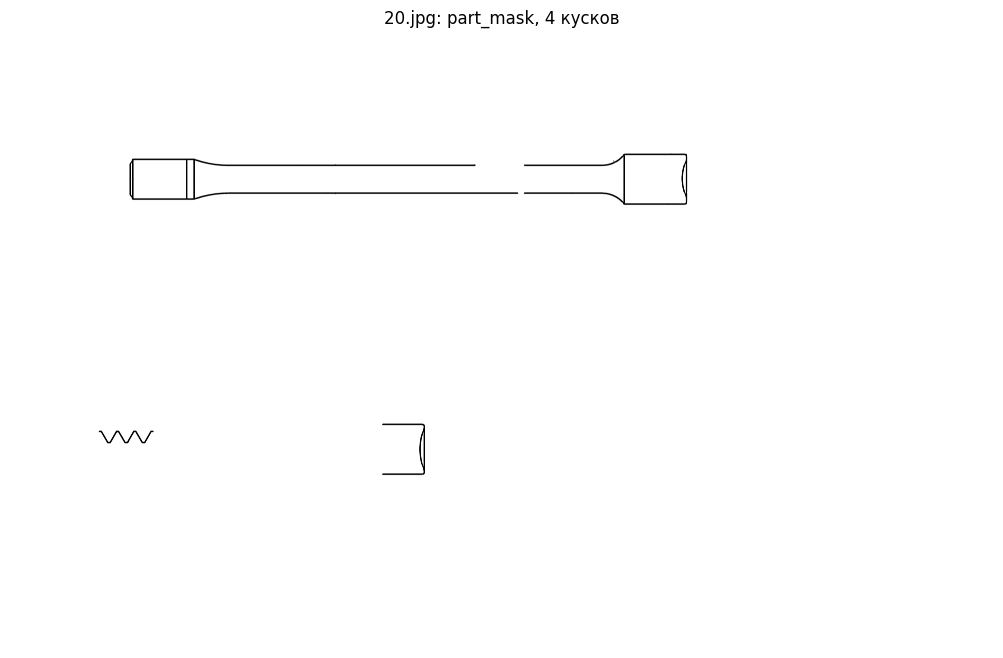

In [1]:
from pathlib import Path

from stage_metrics import measure_mask_metrics
from visualization import show_mask

from draftslice.image_preparation import load_bgr_image
from draftslice.pipeline import run_pipeline
from draftslice.pipeline_parameters import PipelineParameters
from draftslice.text_detection import TextProbabilityDetector

DATASET_FOLDER = Path("../data")
MODEL_PATH = Path("../models/PP-OCRv5_server_det_infer.onnx")
SOURCE_FILE = DATASET_FOLDER / "20.jpg"

parameters = PipelineParameters()
detector = TextProbabilityDetector(MODEL_PATH)

image = load_bgr_image(SOURCE_FILE)
artifacts = run_pipeline(image, detector, parameters)
part_mask = artifacts.part_mask
scaled_image = artifacts.scaled_image

metrics = measure_mask_metrics(part_mask)
print(f"{SOURCE_FILE.name}: {part_mask.shape}, dtype={part_mask.dtype}")
print(f"чернил {metrics.ink_share:.1%} | связных кусков {metrics.component_count}")
show_mask(part_mask, f"{SOURCE_FILE.name}: part_mask, {metrics.component_count} кусков")


## Слияние кусков по зазору между контурами

Разрыв размерной выноски, отверстие внутри контура или условный обрыв длинной детали (волнистая
линия) режут один вид на несколько кусков растра. Куски ищем через `cv2.findContours`, а зазор
между двумя кусками — это минимальное расстояние между настоящими точками их контуров, не между
прямоугольниками (иначе можно случайно решить, что далекие по факту куски рядом). Порог берется не
в пикселях и не долей габарита куска, а числом толщин линии на листе (`strokes_graph.median_thickness`):
разрыв выноски или обрыв детали рисуется пропорционально толщине пера, а не размеру куска, который
он разделяет, поэтому именно толщина линии — общий и устойчивый ориентир для всего листа. Вложенный
габарит (отверстие внутри контура) — это всегда один и тот же вид, порог тут ни при чем.

In [2]:
from ipywidgets import FloatSlider, interactive
from visualization import build_view_window, draw_view_groups, window_sliders

from draftslice.view_extraction import ViewGroups, group_mask_components

line_thickness = artifacts.strokes_graph.median_thickness
print(f"толщина линии на листе: {line_thickness:.1f} px")


def run_view_grouping(merge_gap_thickness: float, center_x: float, center_y: float, zoom: float) -> ViewGroups:
    """Слайдер зазора между кусками как числа толщин линии."""
    groups = group_mask_components(part_mask, line_thickness, merge_gap_thickness)
    print(
        f"кусков было {groups.raw_component_count} | групп стало {groups.group_count} | "
        f"зазор <= {merge_gap_thickness:.1f} толщин линии ({merge_gap_thickness * line_thickness:.0f} px)"
    )

    window = build_view_window(scaled_image.shape[:2], center_x, center_y, zoom)
    draw_view_groups(
        groups.labels, groups.group_count, groups.raw_component_count, scaled_image, window, SOURCE_FILE.name
    )
    return groups


ui_grouping = interactive(
    run_view_grouping,
    merge_gap_thickness=FloatSlider(
        value=8.0, min=0.0, max=20.0, step=0.5, continuous_update=False, description="зазор, толщин"
    ),
    **window_sliders(),
)
ui_grouping

толщина линии на листе: 16.1 px


interactive(children=(FloatSlider(value=8.0, continuous_update=False, description='зазор, толщин', max=20.0, s…

## Кроп каждого вида из чистой маски

Вырезаем из `part_mask` — маски, которую отдаёт весь пайплайн (без текста, без размеров), а не из
исходного изображения: цель этого этапа — подготовить чистую геометрию вида для эмбеддинга, а не
фотографию листа. К габариту группы добавляется отступ (в толщинах линии) и обрезается по границам
кадра, дальше по нему вырезается кусок той же маски.

In [3]:
from ipywidgets import FloatSlider, interactive
from visualization import show_view_crops

from draftslice.view_extraction import extract_view_crops


def run_view_crops(padding_thickness: float) -> list:
    """Слайдер отступа вокруг габарита вида, в толщинах линии."""
    groups = ui_grouping.result
    padding = padding_thickness * line_thickness
    crops = extract_view_crops(part_mask, groups, padding)

    print(f"видов {len(crops)} | отступ {padding_thickness:.1f} толщин линии ({padding:.0f} px)")
    show_view_crops(crops, [f"{SOURCE_FILE.name}: вид {index + 1}" for index in range(len(crops))])
    return crops


ui_crops = interactive(
    run_view_crops,
    padding_thickness=FloatSlider(
        value=3.0, min=0.0, max=20.0, step=0.5, continuous_update=False, description="отступ, толщин"
    ),
)
ui_crops

interactive(children=(FloatSlider(value=3.0, continuous_update=False, description='отступ, толщин', max=20.0, …

## Приведение к размеру модели

Кропы разного размера и соотношения сторон — DINOv3/CLIP ждут на входе фиксированный квадрат.
Растянуть кроп до квадрата по каждой оси отдельно нельзя — это исказит пропорции детали, у которой
именно форма и важна. Масштаб при этом общий для всего листа, а не свой у каждого вида: если считать
его отдельно для каждого кропа, маленькая выноска и длинный вал заполнят свой квадрат одинаково, и
станет не видно, что на самом чертеже они разного размера. Поэтому масштаб берется по самому
крупному виду на листе и применяется ко всем остальным, а свободное поле дополняется пустотой.
Виды на выходе отсортированы от самого крупного к самому мелкому, при близкой площади — сверху вниз
и слева направо по расположению на листе.

In [4]:
from ipywidgets import Dropdown, interactive

from draftslice.view_extraction import normalize_view_crops


def run_resize_crops(target_size: int) -> list:
    """Выбор целевого размера квадрата под конкретную модель эмбеддинга."""
    padding = ui_crops.kwargs["padding_thickness"] * line_thickness
    groups = ui_grouping.result
    resized = normalize_view_crops(part_mask, groups, padding, target_size)

    print(f"видов {len(resized)} | размер {target_size}x{target_size} | масштаб общий на весь лист")
    show_view_crops(
        resized,
        [f"{SOURCE_FILE.name}: вид {index + 1} (от крупного к мелкому)" for index in range(len(resized))],
        row_height=target_size / 100,
    )
    return resized


ui_resized = interactive(
    run_resize_crops,
    target_size=Dropdown(options=[224, 336, 384, 518], value=224, description="размер модели"),
)
ui_resized

interactive(children=(Dropdown(description='размер модели', options=(224, 336, 384, 518), value=224), Output()…